# F1-score vs Training Set Size (with-errors model)

Plot F1-score as a function of training set size (model size) for the DeepCDS full model
trained with sequencing errors, evaluated on the 300 bp `with_errors` test sets.

Three error levels are plotted as separate lines:
- **Low:** 5e-06 indel / 0.004 substitution rate
- **Medium:** 1.25e-05 indel / 0.01 substitution rate
- **High:** 3.75e-05 indel / 0.03 substitution rate

In [2]:
import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import scienceplots

sys.path.insert(0, str(Path(".").resolve().parent))
from plot_config import FONT_SIZES

plt.style.use(["science", "nature"])
plt.rcParams["text.usetex"] = False
plt.rcParams["figure.dpi"] = 300
plt.rcParams.update(FONT_SIZES)

In [3]:
PROJECT_ROOT = Path(".").resolve().parents[3]
TESTSET_DIR = PROJECT_ROOT / "data/processed_data/testset_processed"
PREDS_DIR = (
    PROJECT_ROOT
    / "data/processed_data/predictions/processed_predictions/DeepCDS/model_with_errors"
)
TEST_ACCESSIONS_FILE = (
    PROJECT_ROOT / "data/processed_data/genome_partitions/test_partition_accessions.txt"
)

OVERLAP_CRITERIA = 1.0  # IoU threshold for TP

# Training set sizes: label → folder suffix
DATASET_SIZES = {
    100: "full_model_100_genomes_seed_42_trained_final_8M_no_dropout",
    200: "full_model_200_genomes_seed_42_trained_final_8M_no_dropout",
    400: "full_model_400_genomes_seed_42_trained_final_8M_no_dropout",
    813: "full_model_all_genomes_seed_42_trained_final_8M_no_dropout",
}

# 300 bp with_errors test sets: display label → folder name
ERROR_LEVELS = {
    r"Low error ($5\times10^{-6}$ indel, $0.4\%$ sub)": "with_errors_5e-06i_0.004s_300bp",
    r"Med. error ($1.25\times10^{-5}$ indel, $1\%$ sub)": "with_errors_1.25e-05i_0.01s_300bp",
    r"High error ($3.75\times10^{-5}$ indel, $3\%$ sub)": "with_errors_3.75e-05i_0.03s_300bp",
}

ERROR_COLORS = {
    r"Low error ($5\times10^{-6}$ indel, $0.4\%$ sub)": "#009E73",
    r"Med. error ($1.25\times10^{-5}$ indel, $1\%$ sub)": "#0072B2",
    r"High error ($3.75\times10^{-5}$ indel, $3\%$ sub)": "#D55E00",
}

ERROR_MARKERS = {
    r"Low error ($5\times10^{-6}$ indel, $0.4\%$ sub)": "o",
    r"Med. error ($1.25\times10^{-5}$ indel, $1\%$ sub)": "s",
    r"High error ($3.75\times10^{-5}$ indel, $3\%$ sub)": "^",
}

In [4]:
def get_full_cds(reads_dict: dict) -> dict:
    """Merge CDS fragments split by indel errors into full CDS entries."""
    for read in reads_dict:
        cds_fragments_connections = reads_dict[read]["cds_fragments_connection"]
        cds_coords = reads_dict[read]["cds_coords"]
        indices_to_remove = []

        for cds_frag_mapping in cds_fragments_connections:
            if len(cds_frag_mapping) > 1:
                if len(cds_fragments_connections) != cds_frag_mapping[0] + 1:
                    if len(cds_frag_mapping) == 1:
                        cds_frag_mapping = [i - 1 for i in cds_frag_mapping]
                elif len(cds_fragments_connections) == 1 and cds_frag_mapping == [0, 2]:
                    cds_frag_mapping = [0, 1]
                elif len(cds_fragments_connections) == 1 and cds_frag_mapping == [2, 3, 4]:
                    cds_frag_mapping = [0, 1, 2]

                start_frag = cds_coords[min(cds_frag_mapping)][0]
                end_frag = cds_coords[max(cds_frag_mapping)][1]
                indices_to_remove += cds_frag_mapping
                assert start_frag < end_frag
                cds_coords.append([start_frag, end_frag, "disrupted_rf"])
                reads_dict[read]["cds_coords"] = cds_coords

        for idx in sorted(indices_to_remove, reverse=True):
            cds_coords.pop(idx)

    return reads_dict


def calculate_iou(coord1, coord2) -> float:
    start1, stop1, rf1 = coord1
    start2, stop2, rf2 = coord2
    if rf1 != rf2:
        return 0.0
    inter_start = max(start1, start2)
    inter_stop = min(stop1, stop2)
    if inter_start >= inter_stop:
        return 0.0
    inter_len = inter_stop - inter_start
    union_len = max(stop1, stop2) - min(start1, start2)
    return inter_len / union_len if union_len > 0 else 0.0


def find_matching_genes(predicted_coords, actual_coords, overlap_criteria):
    matched_pairs = []
    used_actual: set = set()
    used_predicted: set = set()

    for pred_idx, pred_coord in enumerate(predicted_coords):
        best_iou = 0.0
        best_actual_idx = -1
        for actual_idx, actual_coord in enumerate(actual_coords):
            if actual_idx in used_actual:
                continue
            iou = calculate_iou(pred_coord, actual_coord)
            if iou >= overlap_criteria and iou > best_iou:
                best_iou = iou
                best_actual_idx = actual_idx
        if best_actual_idx != -1:
            matched_pairs.append((pred_idx, best_actual_idx))
            used_actual.add(best_actual_idx)
            used_predicted.add(pred_idx)

    return matched_pairs, len(matched_pairs)


def aggregate_metrics(testset_dict, preds_dict, read_names_list, overlap_criteria):
    """Return (total_tp, total_predicted, total_actual) across all reads."""
    total_tp = 0
    total_predicted = 0
    total_actual = 0

    for read_name in read_names_list:
        coords_test = []
        coords_pred = []
        if read_name in testset_dict:
            coords_test = testset_dict[read_name].get("cds_coords", [])
        if read_name in preds_dict:
            coords_pred = preds_dict[read_name].get("cds_coords", [])

        _, tp = find_matching_genes(coords_pred, coords_test, overlap_criteria)
        total_tp += tp
        total_predicted += len(coords_pred)
        total_actual += len(coords_test)

    return total_tp, total_predicted, total_actual


def compute_f1(tp, predicted, actual):
    precision = tp / predicted if predicted > 0 else 0.0
    recall = tp / actual if actual > 0 else 0.0
    return (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )

In [5]:
test_accessions = TEST_ACCESSIONS_FILE.read_text().splitlines()
test_accessions = [a for a in test_accessions if a.strip()]
print(f"Test accessions: {len(test_accessions)}")

# results[error_label][training_size] = aggregate F1
results: dict[str, dict[int, float]] = {label: {} for label in ERROR_LEVELS}
# per_genome_f1[error_label][training_size] = list of per-genome F1 scores
per_genome_f1: dict[str, dict[int, list[float]]] = {label: {} for label in ERROR_LEVELS}

for error_label, data_type in ERROR_LEVELS.items():
    print(f"\n=== {data_type} ===")
    testset_base = TESTSET_DIR / data_type

    for size, model_folder in DATASET_SIZES.items():
        preds_base = PREDS_DIR / data_type / model_folder
        total_tp = total_predicted = total_actual = 0
        genome_f1s = []

        skipped = 0
        for accession in test_accessions:
            testset_pkl = testset_base / accession / "testset_dict.pkl"
            read_names_pkl = testset_base / accession / "read_names_list.pkl"
            preds_pkl = preds_base / accession / "model_preds_dict.pkl"

            if not testset_pkl.exists() or not preds_pkl.exists():
                skipped += 1
                continue

            with open(testset_pkl, "rb") as f:
                testset_dict = get_full_cds(pickle.load(f))
            with open(read_names_pkl, "rb") as f:
                read_names_list = pickle.load(f)
            with open(preds_pkl, "rb") as f:
                preds_dict = get_full_cds(pickle.load(f))

            tp, predicted, actual = aggregate_metrics(
                testset_dict, preds_dict, read_names_list, OVERLAP_CRITERIA
            )
            total_tp += tp
            total_predicted += predicted
            total_actual += actual
            genome_f1s.append(compute_f1(tp, predicted, actual))

        f1 = compute_f1(total_tp, total_predicted, total_actual)
        results[error_label][size] = f1
        per_genome_f1[error_label][size] = genome_f1s

Test accessions: 215

=== with_errors_5e-06i_0.004s_300bp ===

=== with_errors_1.25e-05i_0.01s_300bp ===

=== with_errors_3.75e-05i_0.03s_300bp ===


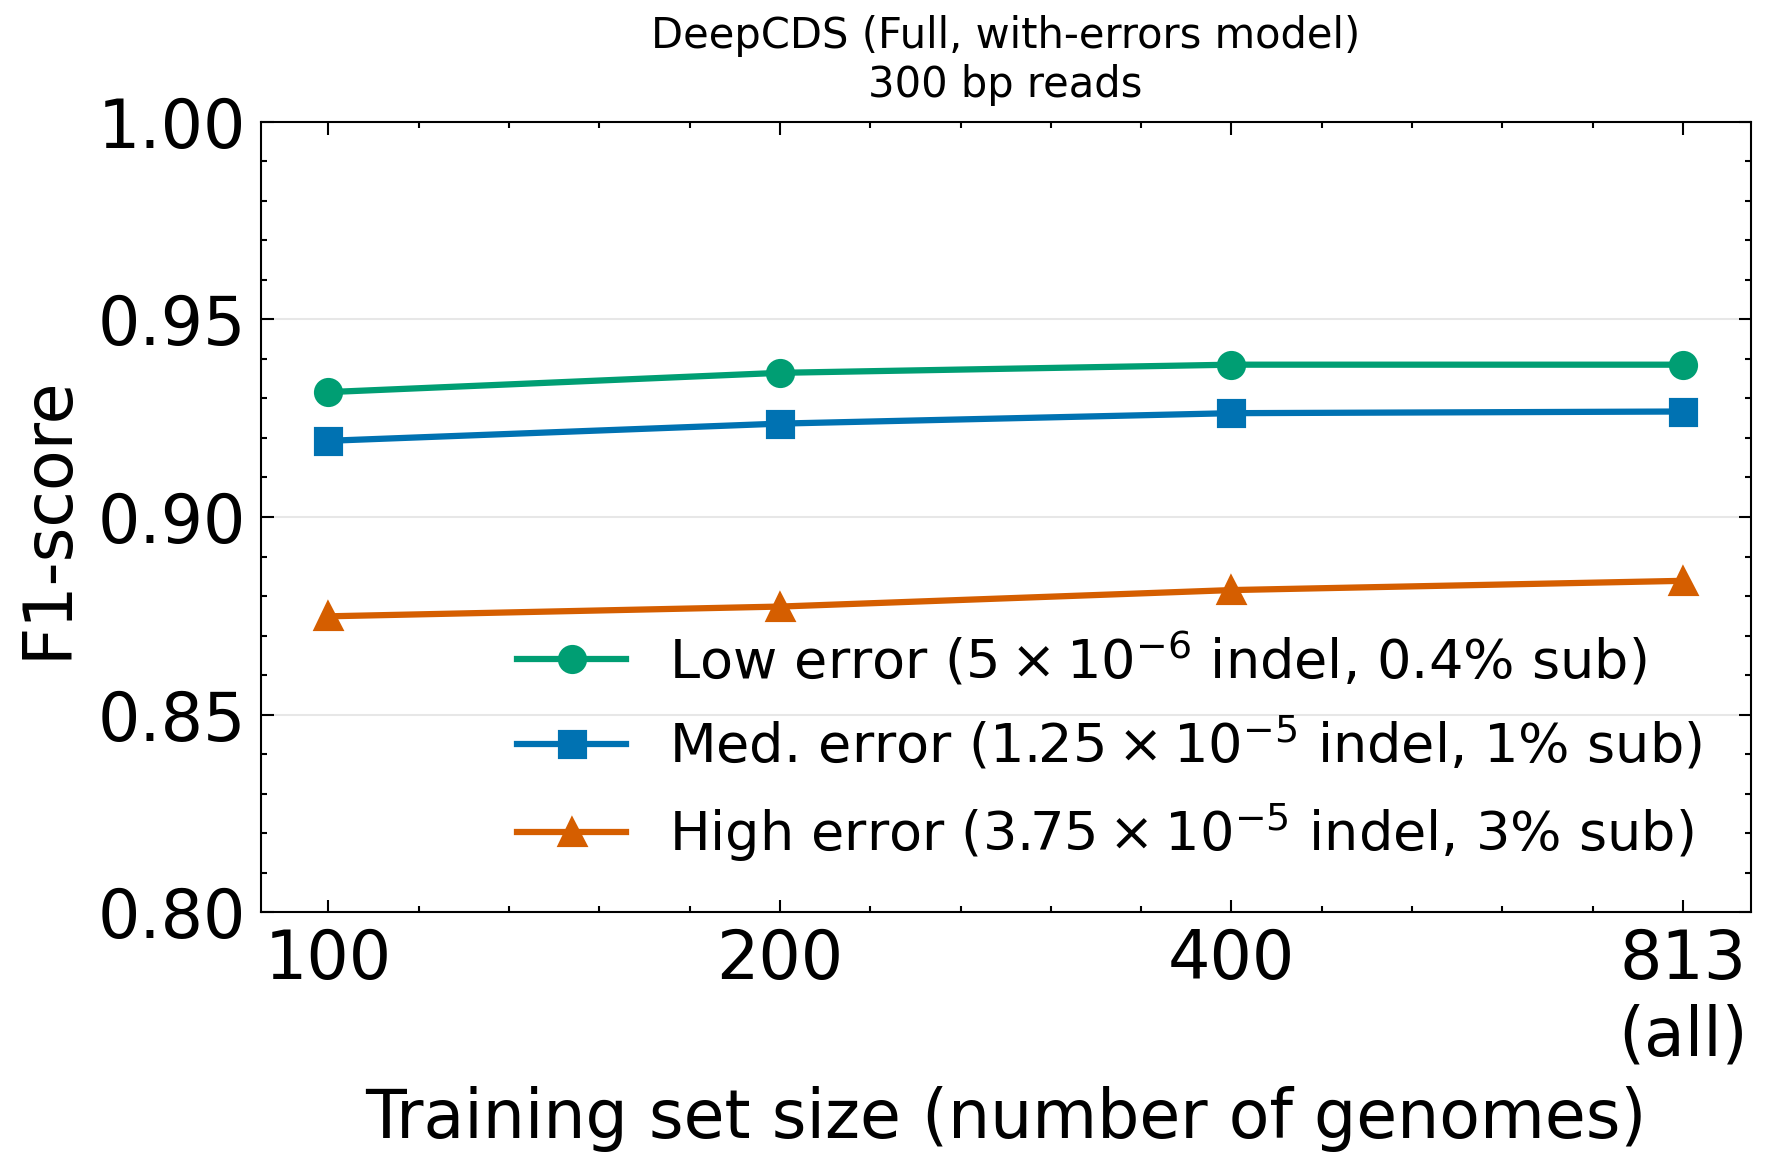

In [6]:
x_vals = sorted(DATASET_SIZES.keys())
x_labels = [str(v) if v != 813 else "813\n(all)" for v in x_vals]

fig, ax = plt.subplots(figsize=(6, 4))

for error_label in ERROR_LEVELS:
    y_vals = [results[error_label][size] for size in x_vals]
    ax.plot(
        range(len(x_vals)),
        y_vals,
        marker=ERROR_MARKERS[error_label],
        color=ERROR_COLORS[error_label],
        label=error_label,
        linewidth=1.5,
        markersize=6,
    )

ax.set_xticks(range(len(x_vals)))
ax.set_xticklabels(x_labels)
ax.set_xlabel("Training set size (number of genomes)")
ax.set_ylabel("F1-score")
ax.set_title("DeepCDS (Full, with-errors model)\n300 bp reads", fontsize=10)
ax.set_ylim(0.8, 1.0)
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3, axis="y")

out_path = Path(".").resolve() / "f1_vs_model_size.pdf"
plt.tight_layout()
# plt.savefig(out_path)
plt.show()

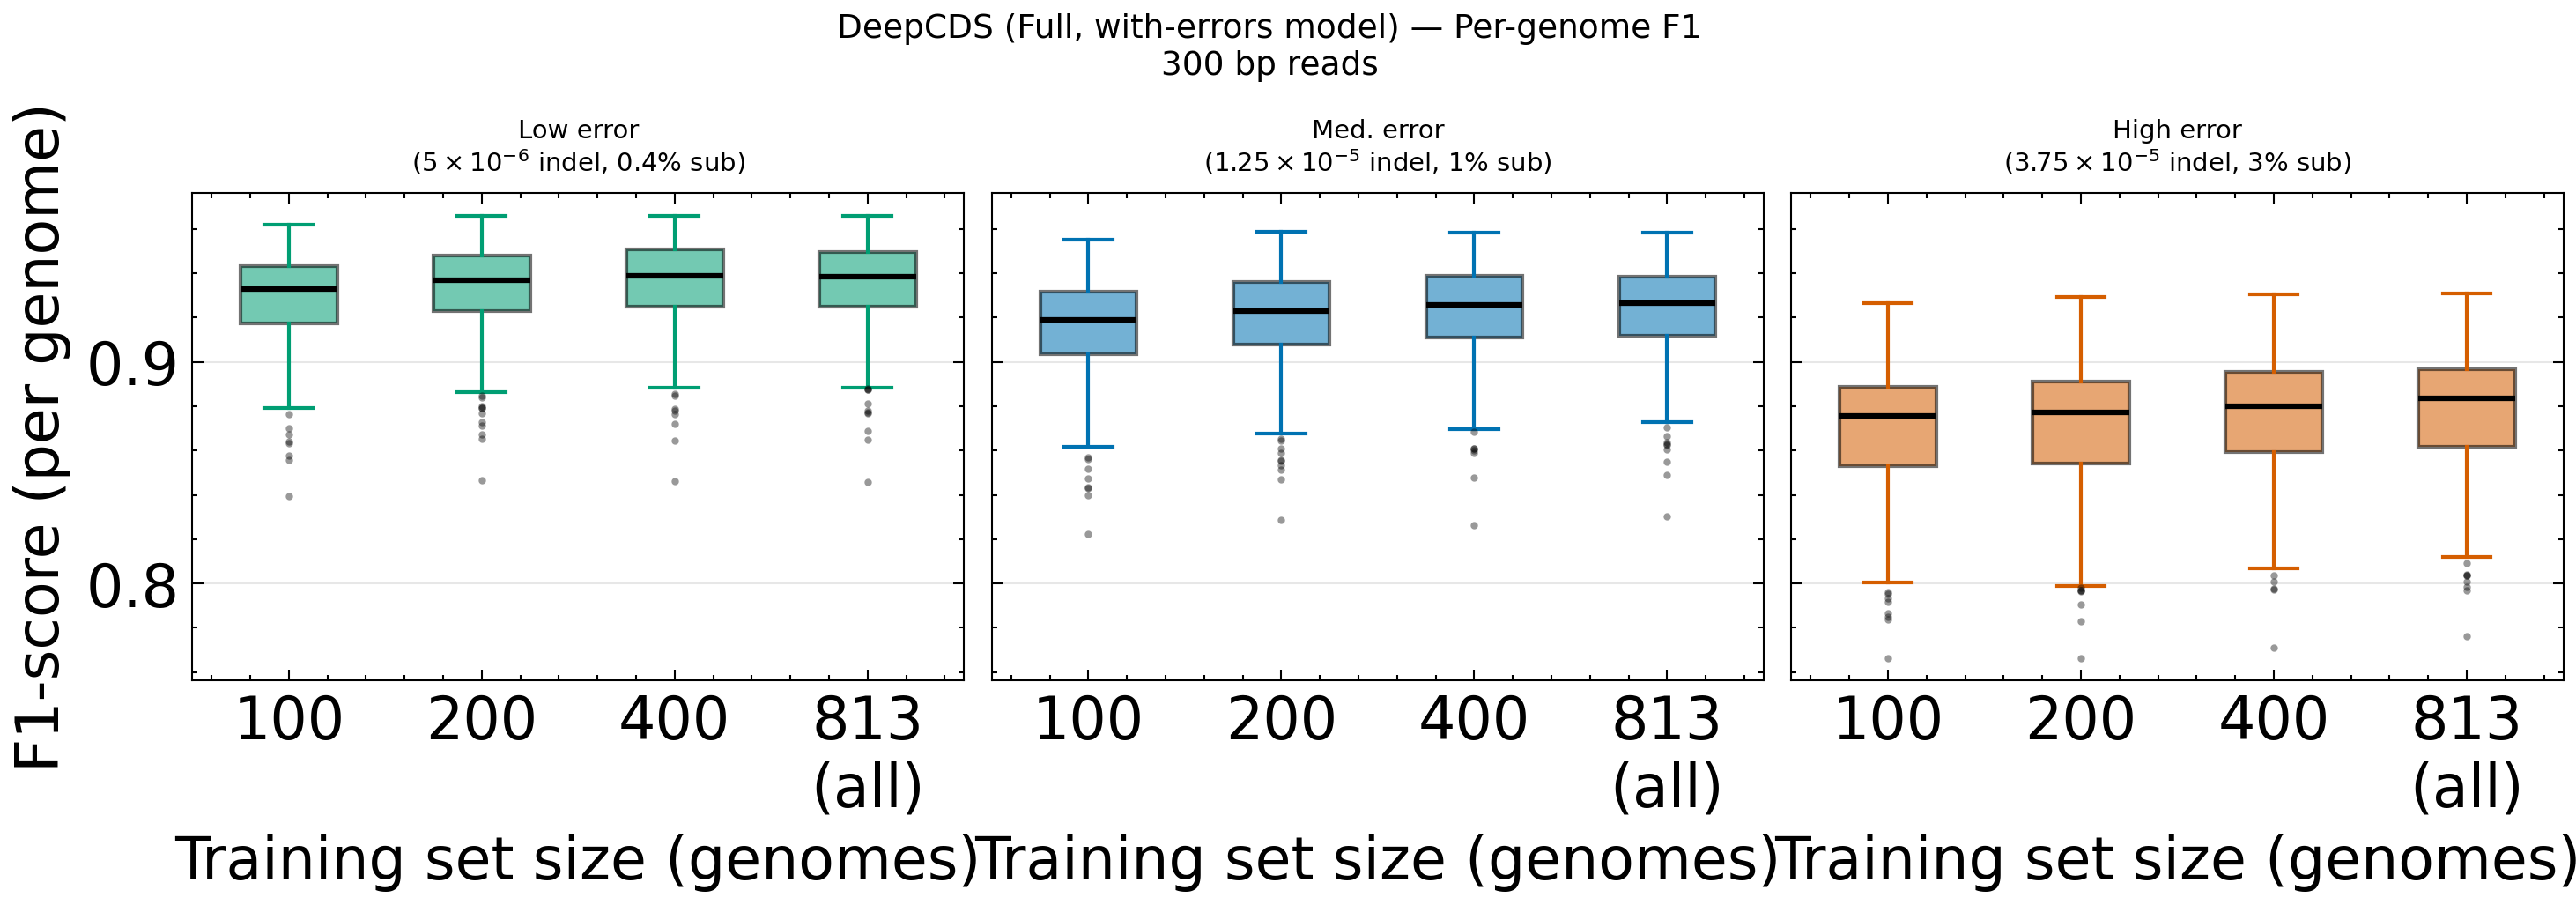

In [7]:
SHORT_ERROR_LABELS = {
    r"Low error ($5\times10^{-6}$ indel, $0.4\%$ sub)": "Low error\n($5\\times10^{-6}$ indel, $0.4\\%$ sub)",
    r"Med. error ($1.25\times10^{-5}$ indel, $1\%$ sub)": "Med. error\n($1.25\\times10^{-5}$ indel, $1\\%$ sub)",
    r"High error ($3.75\times10^{-5}$ indel, $3\%$ sub)": "High error\n($3.75\\times10^{-5}$ indel, $3\\%$ sub)",
}

x_vals_box = sorted(DATASET_SIZES.keys())
x_tick_labels = [str(v) if v != 813 else "813\n(all)" for v in x_vals_box]

fig, axes = plt.subplots(1, 3, figsize=(10, 3.5), sharey=True)

for ax, error_label in zip(axes, ERROR_LEVELS):
    color = ERROR_COLORS[error_label]
    data = [per_genome_f1[error_label][size] for size in x_vals_box]
    bp = ax.boxplot(
        data,
        patch_artist=True,
        widths=0.5,
        medianprops=dict(color="black", linewidth=1.5),
        boxprops=dict(facecolor=color, alpha=0.55),
        whiskerprops=dict(color=color, linewidth=1.0),
        capprops=dict(color=color, linewidth=1.0),
        flierprops=dict(marker=".", color=color, alpha=0.4, markersize=2),
    )
    ax.set_xticks(range(1, len(x_vals_box) + 1))
    ax.set_xticklabels(x_tick_labels)
    ax.set_xlabel("Training set size (genomes)")
    ax.set_title(SHORT_ERROR_LABELS[error_label], fontsize=7)
    ax.grid(True, alpha=0.3, axis="y")

axes[0].set_ylabel("F1-score (per genome)")

fig.suptitle("DeepCDS (Full, with-errors model) — Per-genome F1\n300 bp reads", fontsize=9)
plt.tight_layout()

out_path_box = Path(".").resolve() / "f1_vs_model_size_per_genome_boxplot.pdf"
# plt.savefig(out_path_box)
plt.show()

In [8]:
LATEX_ERROR_HEADERS = {
    r"Low error ($5\times10^{-6}$ indel, $0.4\%$ sub)": r"Low error",
    r"Med. error ($1.25\times10^{-5}$ indel, $1\%$ sub)": r"Med.\ error",
    r"High error ($3.75\times10^{-5}$ indel, $3\%$ sub)": r"High error",
}

error_labels = list(ERROR_LEVELS.keys())
sizes = sorted(DATASET_SIZES.keys())

col_spec = "l" + "c" * len(error_labels)
header_cols = " & ".join(LATEX_ERROR_HEADERS[l] for l in error_labels)

rows = []
for size in sizes:
    size_label = str(size) if size != 813 else "813 (all)"
    cells = []
    for error_label in error_labels:
        agg_f1 = results[error_label][size]
        std = np.std(per_genome_f1[error_label][size])
        cells.append(rf"{agg_f1:.3f} ({std:.3f})")
    rows.append(f"    {size_label} & " + " & ".join(cells) + r" \\")

table = "\n".join([
    r"\begin{table}[ht]",
    r"\centering",
    r"\caption{DeepCDS (full, with-errors model) aggregate F1-score on 300\,bp reads. "
    r"Per-genome standard deviation in parentheses.}",
    r"\label{tab:f1_vs_model_size}",
    rf"\begin{{tabular}}{{{col_spec}}}",
    r"\hline",
    rf"    Training genomes & {header_cols} \\",
    r"\hline",
    *rows,
    r"\hline",
    r"\end{tabular}",
    r"\end{table}",
])

print(table)

\begin{table}[ht]
\centering
\caption{DeepCDS (full, with-errors model) aggregate F1-score on 300\,bp reads. Per-genome standard deviation in parentheses.}
\label{tab:f1_vs_model_size}
\begin{tabular}{lccc}
\hline
    Training genomes & Low error & Med.\ error & High error \\
\hline
    100 & 0.932 (0.022) & 0.919 (0.024) & 0.875 (0.030) \\
    200 & 0.936 (0.022) & 0.924 (0.024) & 0.877 (0.029) \\
    400 & 0.939 (0.021) & 0.926 (0.023) & 0.882 (0.028) \\
    813 (all) & 0.939 (0.021) & 0.927 (0.023) & 0.884 (0.028) \\
\hline
\end{tabular}
\end{table}
